**VÍ DỤ 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
# Tải dữ liệu
data = load_iris()
X = data.data
y = data.target

In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Khởi tạo PCA với 2 thành phần chính
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Kiểm tra tỷ lệ phương sai giữ lại của các thành phần
print("Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính:",
pca.explained_variance_ratio_)
print("Tổng tỷ lệ phương sai giữ lại:", sum(pca.explained_variance_ratio_))

Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính: [0.72962445 0.22850762]
Tổng tỷ lệ phương sai giữ lại: 0.9581320720000166


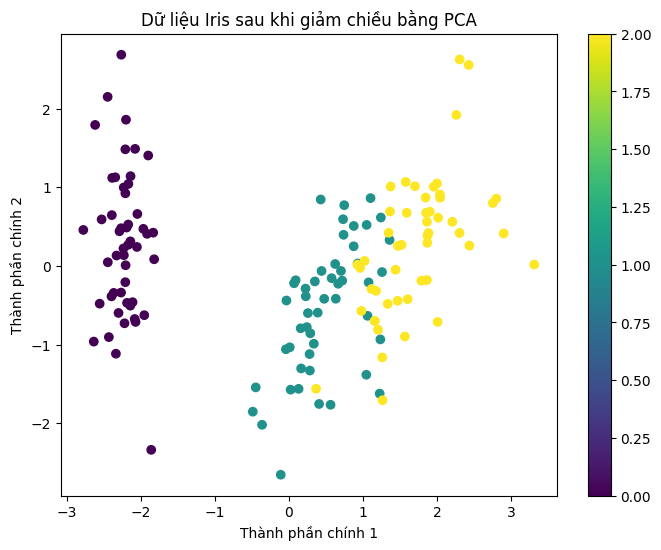

In [ ]:
# Hiển thị dữ liệu trên không gian mới với 2 chiều chính
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel("Thành phần chính 1")
plt.ylabel("Thành phần chính 2")
plt.colorbar()
plt.title("Dữ liệu Iris sau khi giảm chiều bằng PCA")
plt.show()

**VÍ DỤ 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [ ]:
data = load_iris()
X = data.data
y = data.target

In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Giảm chiều dữ liệu với PCA
# Khởi tạo PCA với 2 thành phần chính
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Kiểm tra tỷ lệ phương sai giữ lại của các thành phần
print("Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính:",
pca.explained_variance_ratio_)
print("Tổng tỷ lệ phương sai giữ lại:", sum(pca.explained_variance_ratio_))

Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính: [0.72962445 0.22850762]
Tổng tỷ lệ phương sai giữ lại: 0.9581320720000166


In [ ]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3,
random_state=42)

In [ ]:
# Huấn luyện mô hình SVM trên dữ liệu đã giảm chiều
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [ ]:
# Dự đoán trên tập kiểm tra
y_pred = svm_model.predict(X_test)

Độ chính xác của mô hình SVM sau khi giảm chiều bằng PCA: 0.9333333333333333


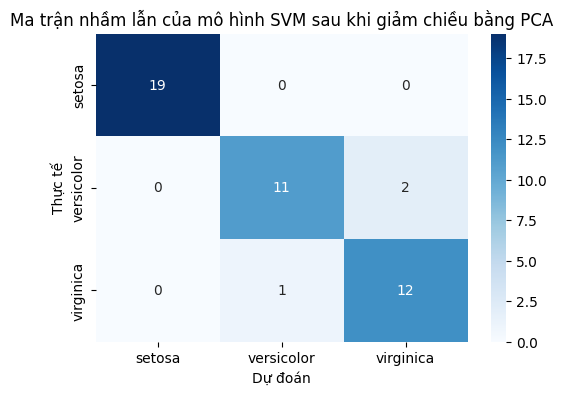

In [ ]:
# Sử dụng các chỉ số như độ chính xác và ma trận nhầm lẫn để đánh giá mô hình.
# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print("Độ chính xác của mô hình SVM sau khi giảm chiều bằng PCA:",
accuracy)
# Ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test, y_pred)
# Hiển thị ma trận nhầm lẫn
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Ma trận nhầm lẫn của mô hình SVM sau khi giảm chiều bằng PCA")
plt.show()

**LDA**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Tải tập dữ liệu Iris
data = load_iris()
X = data.data
y = data.target

In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Áp dụng LDA để giảm số chiều dữ liệu
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

In [ ]:
# Kiểm tra tỷ lệ phương sai giữ lại của các thành phần
print("Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính:",
lda.explained_variance_ratio_)

Tỷ lệ phương sai giữ lại bởi mỗi thành phần chính: [0.9912126 0.0087874]


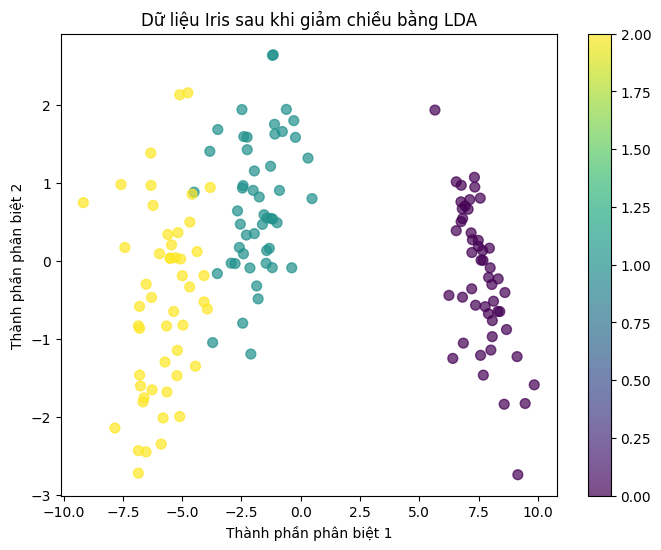

In [ ]:
# Trực quan hóa dữ liệu sau khi giảm chiều
plt.figure(figsize=(8, 6))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.xlabel("Thành phần phân biệt 1")
plt.ylabel("Thành phần phân biệt 2")
plt.title("Dữ liệu Iris sau khi giảm chiều bằng LDA")
plt.colorbar()
plt.show()

In [ ]:
# Áp dụng mô hình phân loại trên dữ liệu đã giảm chiều
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.3,
random_state=42)

In [ ]:
# Khởi tạo và huấn luyện mô hình Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

In [ ]:
# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print("Độ chính xác của mô hình Logistic Regression sau khi giảm chiều bằng LDA:",
accuracy)

Độ chính xác của mô hình Logistic Regression sau khi giảm chiều bằng LDA: 1.0


**BÀI TẬP TẠI LỚP**

**BÀI 1**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
print(f"Kích thước dữ liệu gốc: {X.shape}")

Kích thước dữ liệu gốc: (178, 13)


In [ ]:
# PCA rất nhạy cảm với sự chênh lệch về tỉ lệ (scale) giữa các biến.
# Cần đưa dữ liệu về dạng chuẩn (mean=0, std=1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Khởi tạo PCA mà không giới hạn số thành phần để xem toàn bộ phương sai
pca = PCA()
pca.fit(X_scaled)

PCA()

In [ ]:
# Tỷ lệ phương sai của từng thành phần (Explained Variance Ratio)
exp_var_ratio = pca.explained_variance_ratio_

# Tỷ lệ phương sai tích lũy (Cumulative Variance)
cum_var_ratio = np.cumsum(exp_var_ratio)

# Xác định số lượng thành phần cần thiết để đạt >= 95% phương sai
# np.argmax trả về chỉ số đầu tiên thỏa mãn điều kiện
n_components_95 = np.argmax(cum_var_ratio >= 0.95) + 1

print("\n--- KẾT QUẢ ---")
print(f"Tỷ lệ phương sai từng thành phần:\n{np.round(exp_var_ratio, 4)}")
print(f"Tỷ lệ phương sai tích lũy:\n{np.round(cum_var_ratio, 4)}")
print(f"\n=> Số lượng thành phần chính cần thiết để giữ lại ít nhất 95% phương sai: {n_components_95}")


--- KẾT QUẢ ---
Tỷ lệ phương sai từng thành phần:
[0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193
 0.0174 0.013  0.008 ]
Tỷ lệ phương sai tích lũy:
[0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617
 0.9791 0.992  1.    ]

=> Số lượng thành phần chính cần thiết để giữ lại ít nhất 95% phương sai: 10


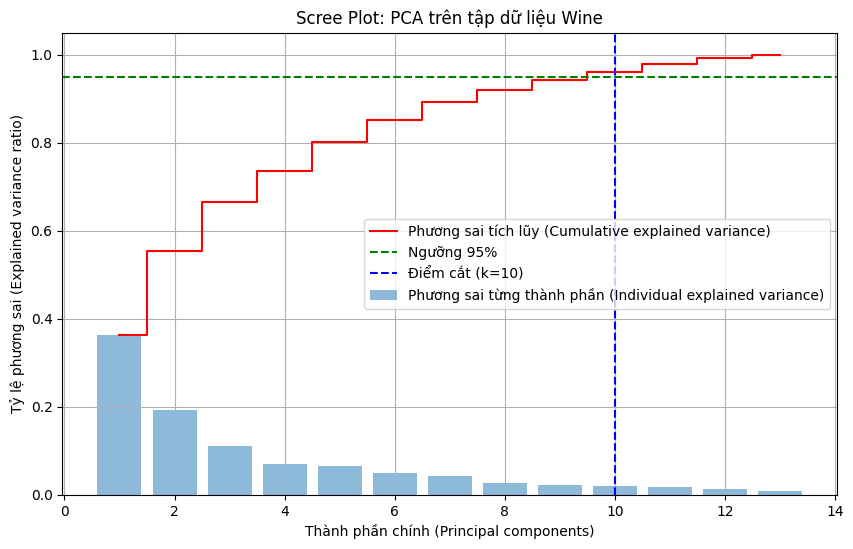

In [ ]:
plt.figure(figsize=(10, 6))

x_axis = range(1, len(exp_var_ratio) + 1)

# Vẽ biểu đồ cột (Scree Plot) cho phương sai từng thành phần
plt.bar(x_axis, exp_var_ratio, alpha=0.5, align='center',
        label='Phương sai từng thành phần (Individual explained variance)')

# Vẽ biểu đồ đường cho phương sai tích lũy
plt.step(x_axis, cum_var_ratio, where='mid', color='red',
         label='Phương sai tích lũy (Cumulative explained variance)')

# Vẽ đường cắt ngang tại ngưỡng 95%
plt.axhline(y=0.95, color='green', linestyle='--', label='Ngưỡng 95%')
plt.axvline(x=n_components_95, color='blue', linestyle='--', label=f'Điểm cắt (k={n_components_95})')

plt.ylabel('Tỷ lệ phương sai (Explained variance ratio)')
plt.xlabel('Thành phần chính (Principal components)')
plt.title('Scree Plot: PCA trên tập dữ liệu Wine')
plt.legend(loc='best')
plt.grid(True)
plt.show()

**BÀI 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Thư viện cho biểu đồ 3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

In [ ]:
# PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

In [ ]:
# ---  Tính toán và so sánh phương sai ---
var_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
var_3d = np.sum(pca_3d.explained_variance_ratio_) * 100

print(f"Tổng phương sai giữ lại (2D): {var_2d:.2f}%")
print(f"Tổng phương sai giữ lại (3D): {var_3d:.2f}%")
print(f"Chênh lệch (thông tin tăng thêm khi dùng 3D): {var_3d - var_2d:.2f}%")

Tổng phương sai giữ lại (2D): 95.81%
Tổng phương sai giữ lại (3D): 99.48%
Chênh lệch (thông tin tăng thêm khi dùng 3D): 3.67%


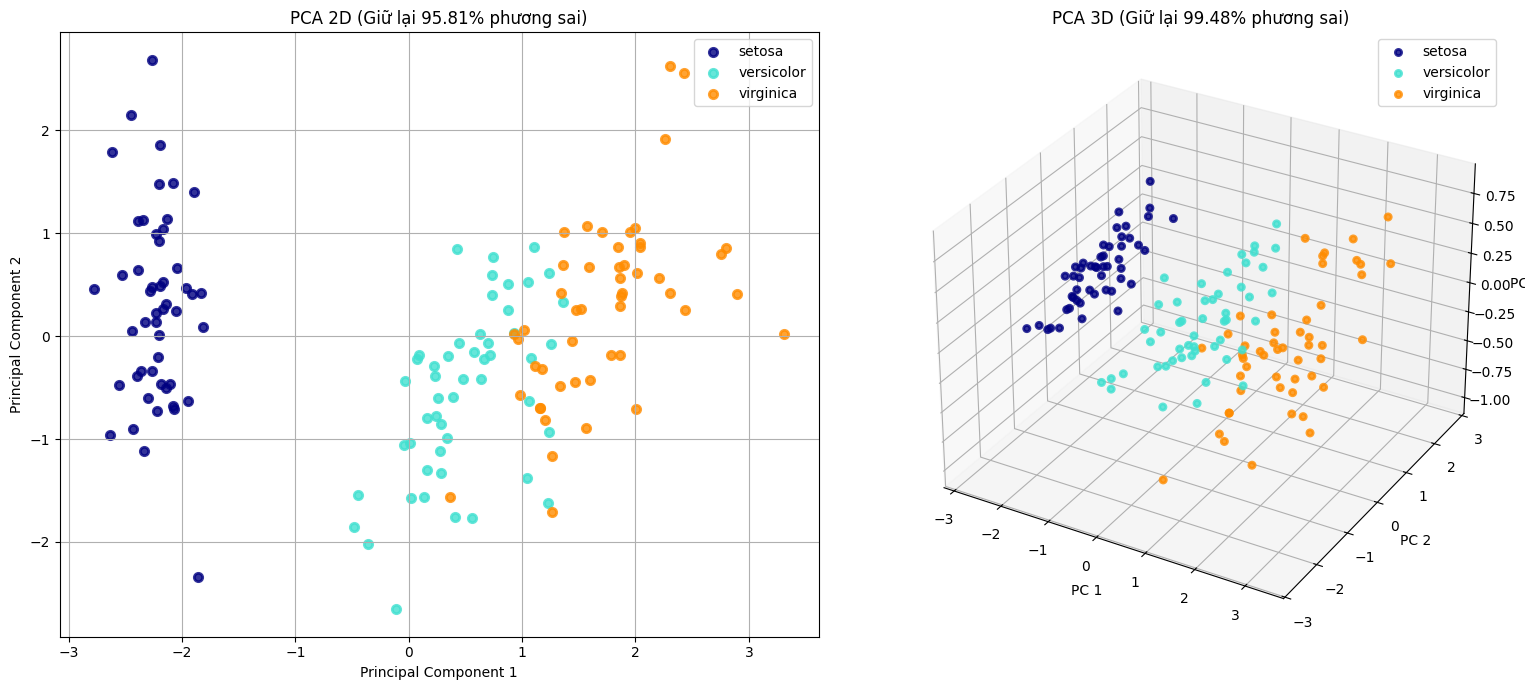

In [ ]:
# ---  Trực quan hóa dữ liệu ---

fig = plt.figure(figsize=(16, 7))

# Biểu đồ 1: PCA 2D
ax1 = fig.add_subplot(1, 2, 1)
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax1.scatter(X_pca_2d[y == i, 0], X_pca_2d[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)
ax1.legend(loc='best', shadow=False, scatterpoints=1)
ax1.set_title(f'PCA 2D (Giữ lại {var_2d:.2f}% phương sai)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True)

# Biểu đồ 2: PCA 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax2.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2],
                color=color, alpha=.8, lw=lw, label=target_name)

ax2.set_title(f'PCA 3D (Giữ lại {var_3d:.2f}% phương sai)')
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax2.set_zlabel('PC 3')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

**BÀI 3**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

print(f"Kích thước dữ liệu gốc: {X.shape} (13 đặc trưng)")
print(f"Số lượng lớp (classes): {len(target_names)} {target_names}")

Kích thước dữ liệu gốc: (178, 13) (13 đặc trưng)
Số lượng lớp (classes): 3 ['class_0' 'class_1' 'class_2']


In [ ]:
# Dù LDA ít nhạy cảm với scaling hơn PCA, nhưng việc chuẩn hóa vẫn được khuyến nghị
# để thuật toán hội tụ tốt hơn và tránh ảnh hưởng bởi đơn vị đo lường.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# QUAN TRỌNG: Số lượng thành phần tối đa trong LDA = min(n_features, n_classes - 1)
# Ở đây: n_features = 13, n_classes = 3.
# => Số chiều tối đa LDA có thể tạo ra là min(13, 3-1) = 2.
lda = LinearDiscriminantAnalysis(n_components=None) # None để giữ lại tối đa có thể
X_lda = lda.fit_transform(X_scaled, y)

In [ ]:
# Trong LDA, đây là "tỷ lệ khả năng phân tách" (discriminability) mà thành phần đó đóng góp
exp_var_ratio = lda.explained_variance_ratio_

print("\n--- KẾT QUẢ ---")
print(f"Số lượng thành phần LDA tạo ra: {len(exp_var_ratio)}")
print(f"Tỷ lệ khả năng phân tách của từng thành phần: {np.round(exp_var_ratio, 4)}")
print(f"Tổng khả năng phân tách tích lũy: {np.round(np.sum(exp_var_ratio), 4)}")


--- KẾT QUẢ ---
Số lượng thành phần LDA tạo ra: 2
Tỷ lệ khả năng phân tách của từng thành phần: [0.6875 0.3125]
Tổng khả năng phân tách tích lũy: 1.0


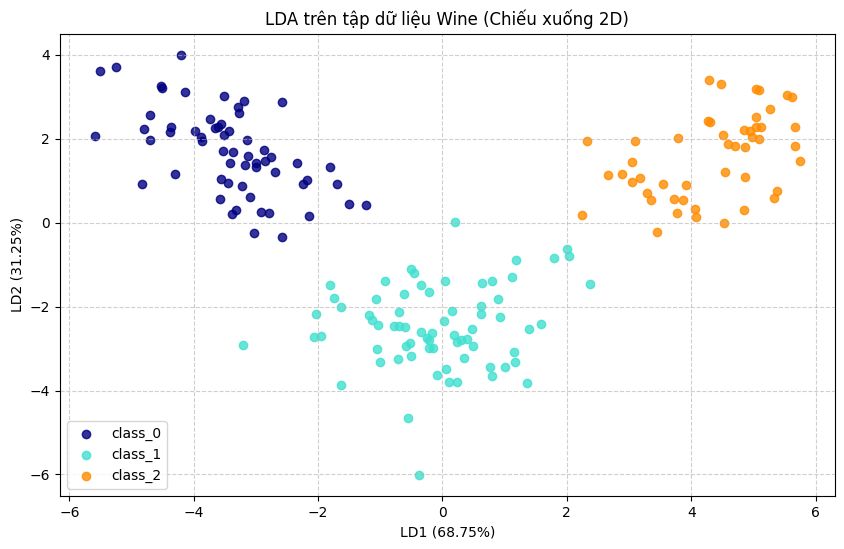

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=.8, color=color,
                label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA trên tập dữ liệu Wine (Chiếu xuống 2D)')
plt.xlabel(f'LD1 ({exp_var_ratio[0]*100:.2f}%)')
plt.ylabel(f'LD2 ({exp_var_ratio[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**BÀI TẬP VỀ NHÀ**

**BÀI 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
from scipy.stats import mode

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target
print(f"Kích thước dữ liệu gốc: {X.shape} (64 đặc trưng)")

Kích thước dữ liệu gốc: (1797, 64) (64 đặc trưng)


In [ ]:
# Chuẩn hóa dữ liệu để PCA hoạt động tốt hơn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Thực hiện PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Kích thước dữ liệu sau PCA: {X_pca.shape}")

Kích thước dữ liệu sau PCA: (1797, 2)


In [ ]:
# Chúng ta biết có 10 chữ số (0-9) nên chọn k=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_pca)


--- KẾT QUẢ ĐÁNH GIÁ ---
Độ chính xác (Accuracy): 53.87%
Adjusted Rand Index (ARI): 0.3259 (Càng gần 1 càng tốt)


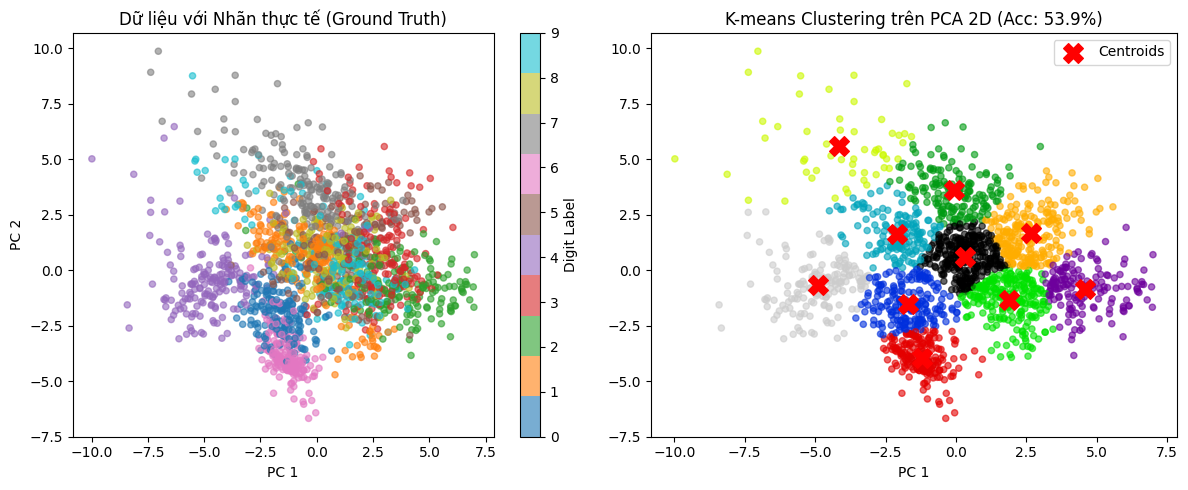

In [ ]:
# HÀM ÁNH XẠ NHÃN (Label Mapping)
# Vì K-means gán nhãn ngẫu nhiên (VD: Cụm số '0' của K-means có thể là số '5' thực tế)
# Ta cần gán lại nhãn của mỗi cụm theo nhãn thực tế xuất hiện nhiều nhất trong cụm đó.
def map_cluster_to_label(kmeans_labels, true_labels):
    labels_mapped = np.zeros_like(kmeans_labels)
    for i in range(10):
        # Lấy các chỉ số (index) của dữ liệu thuộc cụm i
        mask = (kmeans_labels == i)
        # Tìm nhãn thực tế phổ biến nhất trong cụm i
        if np.sum(mask) > 0:
            most_common = mode(true_labels[mask], keepdims=True)[0][0]
            labels_mapped[mask] = most_common
    return labels_mapped

y_pred_mapped = map_cluster_to_label(y_pred, y)

# Tính độ chính xác
acc = accuracy_score(y, y_pred_mapped)
ari = adjusted_rand_score(y, y_pred) # Chỉ số Rand điều chỉnh (không cần map nhãn)

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"Độ chính xác (Accuracy): {acc*100:.2f}%")
print(f"Adjusted Rand Index (ARI): {ari:.4f} (Càng gần 1 càng tốt)")

# --- Trực quan hóa ---
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Nhãn thực tế (Ground Truth)
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=20, alpha=0.6)
plt.title('Dữ liệu với Nhãn thực tế (Ground Truth)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar(label='Digit Label')

# Biểu đồ 2: Kết quả phân cụm K-means
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='nipy_spectral', s=20, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title(f'K-means Clustering trên PCA 2D (Acc: {acc*100:.1f}%)')
plt.xlabel('PC 1')
plt.legend()

plt.tight_layout()
plt.show()

**BÀI 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
# Việc này rất quan trọng để đánh giá khách quan, tránh Overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("--- 1. Huấn luyện trên Dữ liệu gốc (64 chiều) ---")
# Tăng max_iter để mô hình hội tụ vì dữ liệu nhiều chiều
log_reg_orig = LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs')
log_reg_orig.fit(X_train_scaled, y_train)

--- 1. Huấn luyện trên Dữ liệu gốc (64 chiều) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='auto')

In [ ]:
y_pred_orig = log_reg_orig.predict(X_test_scaled)
acc_orig = accuracy_score(y_test, y_pred_orig)
print(f"Độ chính xác (Original): {acc_orig:.4f} ({acc_orig*100:.2f}%)")

Độ chính xác (Original): 0.9704 (97.04%)


In [ ]:
print("\n--- 2. Huấn luyện trên Dữ liệu LDA (9 chiều) ---")
lda = LinearDiscriminantAnalysis(n_components=9)

# Fit LDA trên tập train và transform cả train lẫn test
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)


--- 2. Huấn luyện trên Dữ liệu LDA (9 chiều) ---


In [ ]:
log_reg_lda = LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs')
log_reg_lda.fit(X_train_lda, y_train)

y_pred_lda = log_reg_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)
print(f"Độ chính xác (LDA Reduced): {acc_lda:.4f} ({acc_lda*100:.2f}%)")

Độ chính xác (LDA Reduced): 0.9500 (95.00%)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- SO SÁNH ---
Chênh lệch độ chính xác: -0.0204
=> LDA làm giảm nhẹ độ chính xác nhưng giảm đáng kể chi phí tính toán.


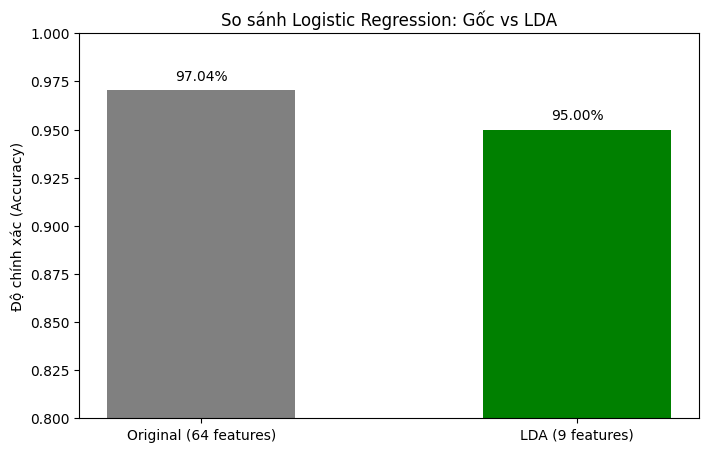

In [ ]:
print("\n--- SO SÁNH ---")
print(f"Chênh lệch độ chính xác: {acc_lda - acc_orig:.4f}")
if acc_lda >= acc_orig:
    print("=> LDA giúp cải thiện hoặc giữ nguyên độ chính xác với số chiều ít hơn rất nhiều.")
else:
    print("=> LDA làm giảm nhẹ độ chính xác nhưng giảm đáng kể chi phí tính toán.")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(8, 5))
labels = ['Original (64 features)', 'LDA (9 features)']
accuracies = [acc_orig, acc_lda]

bars = plt.bar(labels, accuracies, color=['gray', 'green'], width=0.5)
plt.ylim(0.8, 1.0) # Giới hạn trục y để nhìn rõ sự khác biệt
plt.ylabel('Độ chính xác (Accuracy)')
plt.title('So sánh Logistic Regression: Gốc vs LDA')

# Hiển thị số liệu trên cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval*100:.2f}%", ha='center')

plt.show()